In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set professional plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Read data
df = pd.read_csv('../results/mpi_strong_results.csv')
print("MPI Strong Scaling Data (Fixed Problem Size):")
print(df)

MPI Strong Scaling Data (Fixed Problem Size):
   Nodes  Tasks  ThreadsPerTask  TotalTime  CommTime  CompTime  Speedup  \
0      1      1             128   0.615344  0.039110  0.379578   1.0000   
1      2      2             128   0.439441  0.059494  0.226575   1.4002   
2      4      4             128   0.323577  0.067921  0.144863   1.9016   

   Efficiency  
0      1.0000  
1      0.7001  
2      0.4754  


✅ Saved: mpi_strong_speedup.png


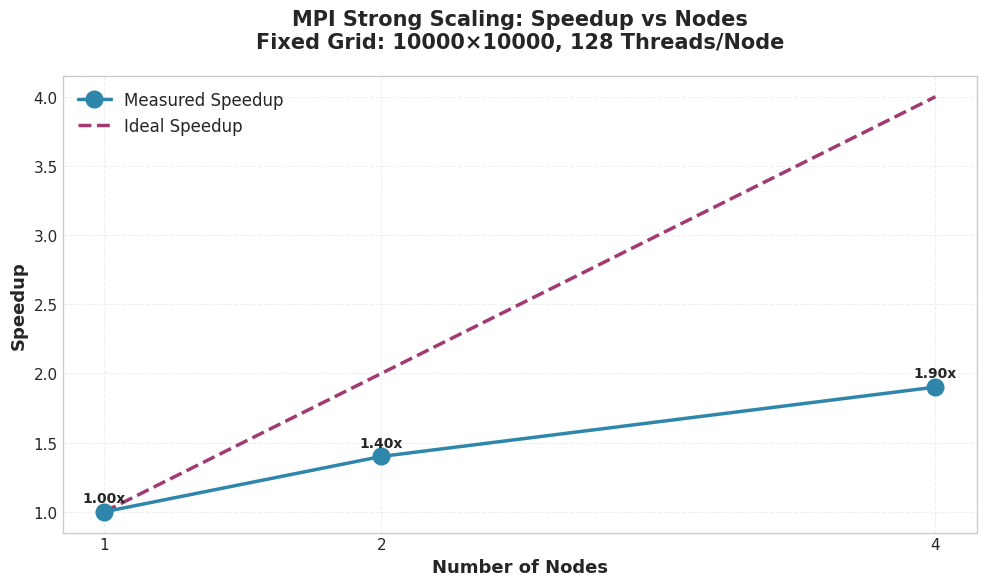

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

# Measured speedup
ax.plot(df['Nodes'], df['Speedup'], 
        'o-', linewidth=2.5, markersize=12, 
        color='#2E86AB', label='Measured Speedup', zorder=3)

# Ideal speedup
ax.plot(df['Nodes'], df['Nodes'], 
        '--', linewidth=2.5, 
        color='#A23B72', label='Ideal Speedup', zorder=2)

ax.set_xlabel('Number of Nodes', fontsize=13, fontweight='bold')
ax.set_ylabel('Speedup', fontsize=13, fontweight='bold')
ax.set_title('MPI Strong Scaling: Speedup vs Nodes\nFixed Grid: 10000×10000, 128 Threads/Node', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(df['Nodes'])
ax.set_xticklabels(df['Nodes'])

# Add value labels on points
for i, row in df.iterrows():
    ax.text(row['Nodes'], row['Speedup'] + 0.05, 
            f"{row['Speedup']:.2f}x",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('mpi_strong_speedup.png', dpi=300, bbox_inches='tight')
print("✅ Saved: mpi_strong_speedup.png")
plt.show()

✅ Saved: mpi_strong_efficiency.png


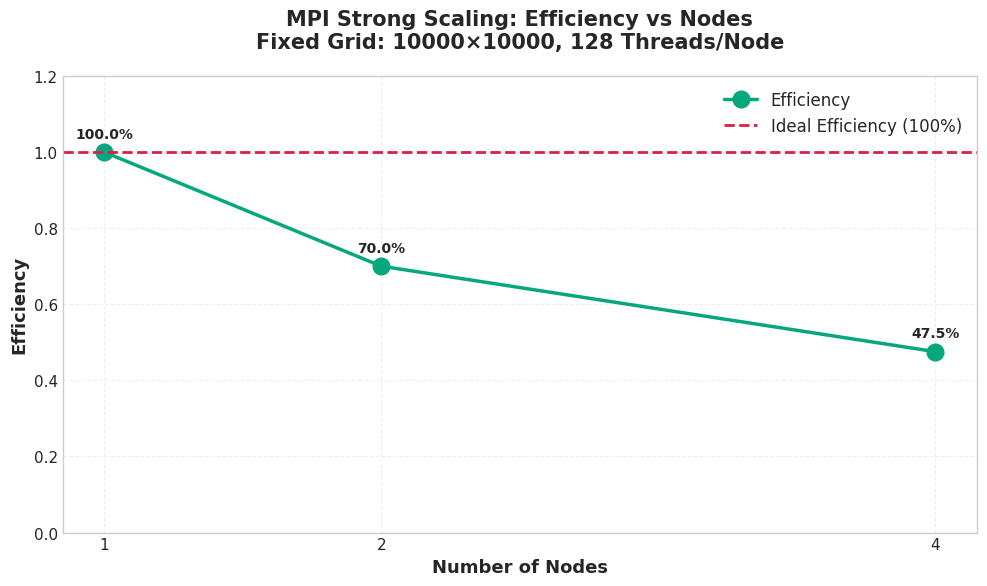

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['Nodes'], df['Efficiency'], 
        'o-', linewidth=2.5, markersize=12, 
        color='#06A77D', label='Efficiency')

# Ideal efficiency
ax.axhline(y=1.0, color='#D62246', linestyle='--', linewidth=2, label='Ideal Efficiency (100%)')

ax.set_xlabel('Number of Nodes', fontsize=13, fontweight='bold')
ax.set_ylabel('Efficiency', fontsize=13, fontweight='bold')
ax.set_title('MPI Strong Scaling: Efficiency vs Nodes\nFixed Grid: 10000×10000, 128 Threads/Node', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(df['Nodes'])
ax.set_xticklabels(df['Nodes'])
ax.set_ylim([0, 1.2])

# Add percentage labels
for i, row in df.iterrows():
    ax.text(row['Nodes'], row['Efficiency'] + 0.03, 
            f"{row['Efficiency']*100:.1f}%",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('mpi_strong_efficiency.png', dpi=300, bbox_inches='tight')
print("✅ Saved: mpi_strong_efficiency.png")
plt.show()

✅ Saved: mpi_strong_commtime.png


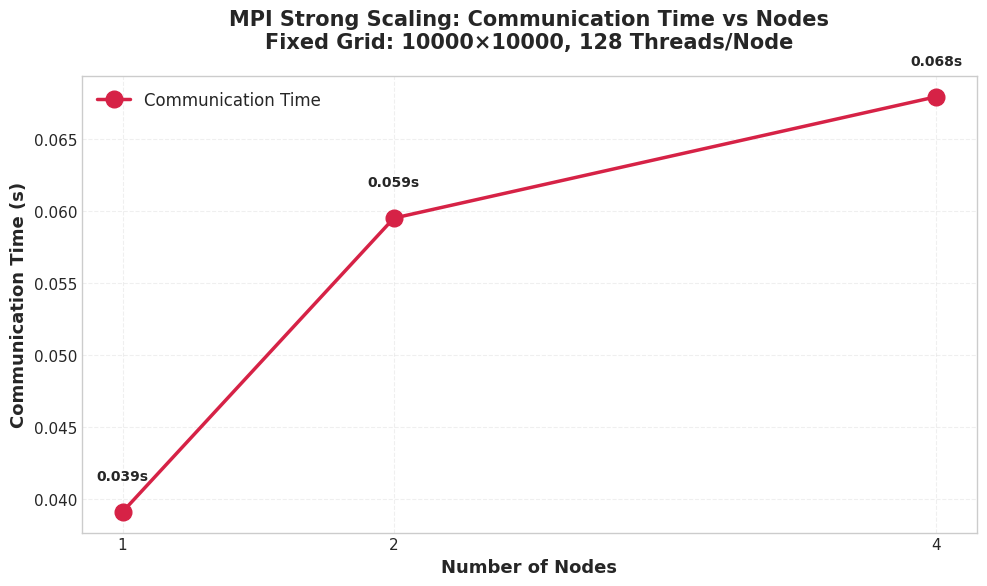

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['Nodes'], df['CommTime'], 
        'o-', linewidth=2.5, markersize=12, 
        color='#D62246', label='Communication Time')

ax.set_xlabel('Number of Nodes', fontsize=13, fontweight='bold')
ax.set_ylabel('Communication Time (s)', fontsize=13, fontweight='bold')
ax.set_title('MPI Strong Scaling: Communication Time vs Nodes\nFixed Grid: 10000×10000, 128 Threads/Node', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(df['Nodes'])
ax.set_xticklabels(df['Nodes'])

# Add value labels
for i, row in df.iterrows():
    ax.text(row['Nodes'], row['CommTime'] + 0.002, 
            f"{row['CommTime']:.3f}s",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('mpi_strong_commtime.png', dpi=300, bbox_inches='tight')
print("✅ Saved: mpi_strong_commtime.png")
plt.show()

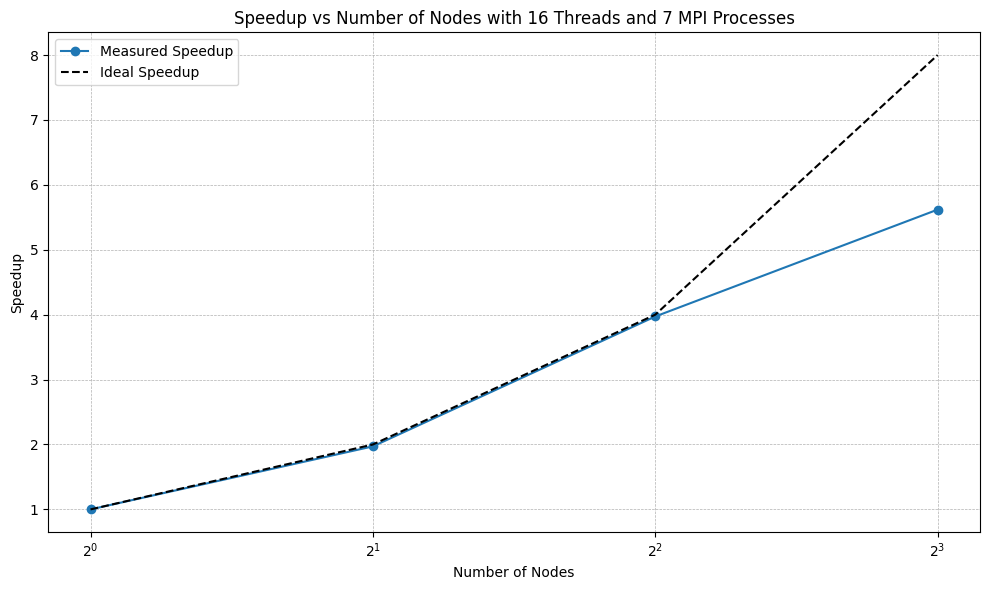

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(df['node'], df['Speedup'], marker='o', label='Measured Speedup')
plt.plot(df['node'], df['node'], 'k--', label='Ideal Speedup')  # Ideal: speedup = threads
plt.xlabel('Number of Nodes')
plt.ylabel('Speedup')
plt.title('Speedup vs Number of Nodes with 16 Threads and 7 MPI Processes')
plt.xscale('log', base=2)
plt.xticks(df['node'])
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

✅ Saved: mpi_strong_comptime.png


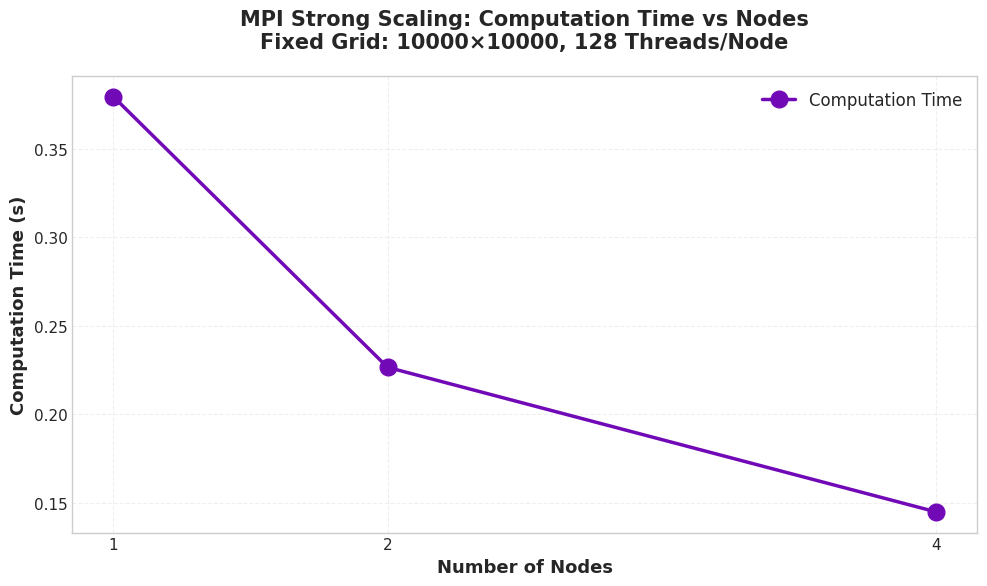

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['Nodes'], df['CompTime'], 
        'o-', linewidth=2.5, markersize=12, 
        color='#7209B7', label='Computation Time')

ax.set_xlabel('Number of Nodes', fontsize=13, fontweight='bold')
ax.set_ylabel('Computation Time (s)', fontsize=13, fontweight='bold')
ax.set_title('MPI Strong Scaling: Computation Time vs Nodes\nFixed Grid: 10000×10000, 128 Threads/Node', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(df['Nodes'])
ax.set_xticklabels(df['Nodes'])

plt.tight_layout()
plt.savefig('mpi_strong_comptime.png', dpi=300, bbox_inches='tight')
print("✅ Saved: mpi_strong_comptime.png")
plt.show()

✅ Saved: mpi_strong_comm_overhead.png


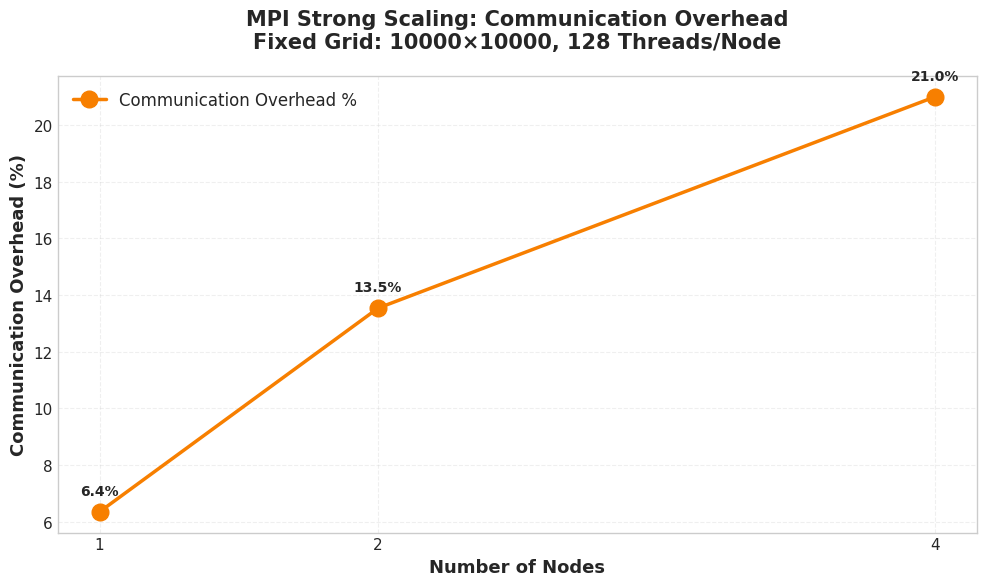

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

df['CommPercent'] = (df['CommTime'] / df['TotalTime']) * 100

ax.plot(df['Nodes'], df['CommPercent'], 
        'o-', linewidth=2.5, markersize=12, 
        color='#F77F00', label='Communication Overhead %')

ax.set_xlabel('Number of Nodes', fontsize=13, fontweight='bold')
ax.set_ylabel('Communication Overhead (%)', fontsize=13, fontweight='bold')
ax.set_title('MPI Strong Scaling: Communication Overhead\nFixed Grid: 10000×10000, 128 Threads/Node', 
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(df['Nodes'])
ax.set_xticklabels(df['Nodes'])

# Add percentage labels
for i, row in df.iterrows():
    comm_pct = (row['CommTime'] / row['TotalTime']) * 100
    ax.text(row['Nodes'], comm_pct + 0.5, 
            f"{comm_pct:.1f}%",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('mpi_strong_comm_overhead.png', dpi=300, bbox_inches='tight')
print("✅ Saved: mpi_strong_comm_overhead.png")
plt.show()

In [12]:
print("\n" + "="*60)
print("MPI STRONG SCALING ANALYSIS SUMMARY")
print("="*60)
print(f"Problem Size: 10000×10000 (fixed)")
print(f"Threads per Node: 128")
print(f"\nScaling Results (1 → {df['Nodes'].max()} nodes):")
print(f"  Final Speedup: {df.iloc[-1]['Speedup']:.2f}x")
print(f"  Final Efficiency: {df.iloc[-1]['Efficiency']*100:.1f}%")
print(f"  Communication Overhead: {df.iloc[0]['CommTime']/df.iloc[0]['TotalTime']*100:.1f}% → {df.iloc[-1]['CommTime']/df.iloc[-1]['TotalTime']*100:.1f}%")
print(f"\nBottleneck Analysis:")
print(f"  Efficiency Drop: {(df.iloc[0]['Efficiency'] - df.iloc[-1]['Efficiency'])*100:.1f}%")
print(f"  Cause: Communication overhead increases with nodes (halo exchange)")
print("="*60)


MPI STRONG SCALING ANALYSIS SUMMARY
Problem Size: 10000×10000 (fixed)
Threads per Node: 128

Scaling Results (1 → 4 nodes):
  Final Speedup: 1.90x
  Final Efficiency: 47.5%
  Communication Overhead: 6.4% → 21.0%

Bottleneck Analysis:
  Efficiency Drop: 52.5%
  Cause: Communication overhead increases with nodes (halo exchange)
